# Z-Score Method for Outlier Detection

The **Z-Score** measures how far a data point is from the mean in terms of standard deviations.

It is commonly used to identify potential outliers in numerical data.

#### Formula

Z = (X - μ) / σ

Where:

- X = Data point
- μ = Mean of the data
- σ = Standard deviation

A commonly used rule is:

- Z-Score > 3 → Potential outlier
- Z-Score < -3 → Potential outlier
- -3 ≤ Z-Score ≤ 3 → Usually considered normal

The threshold can be adjusted depending on the problem and distribution.

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Salary": [
        30000, 32000, 35000, 36000, 38000,
        40000, 42000, 45000, 47000, 50000,
        200000
    ]
})

df

,Salary
0,30000
1,32000
2,35000
3,36000
4,38000
5,40000
6,42000
7,45000
8,47000
9,50000


#### Calculating the Mean

The mean represents the average value of the dataset.

The Z-Score uses the mean as the center point for measuring how far each observation is from the average.

In [2]:
mean = df["Salary"].mean()

print("Mean:", mean)

Mean: 54090.90909090909


#### Calculating Standard Deviation

Standard deviation measures how spread out the observations are around the mean.

A larger standard deviation means the values are more spread out.

A smaller standard deviation means the values are closer to the mean.

In [3]:
std = df["Salary"].std()

print("Standard Deviation:", std)

Standard Deviation: 48788.22510699594


### Calculating Z-Score Manually

We can calculate the Z-Score using:

Z = (X - μ) / σ

For every observation:

1. Subtract the mean from the observation.
2. Divide the result by the standard deviation.
3. The result is the Z-Score.

In [4]:
df["Z_Score"] = (
    (df["Salary"] - mean) / std
)

df

,Salary,Z_Score
0,30000,-0.493785
1,32000,-0.452792
2,35000,-0.391302
3,36000,-0.370805
4,38000,-0.329811
5,40000,-0.288818
6,42000,-0.247824
7,45000,-0.186334
8,47000,-0.145341
9,50000,-0.083850


#### Detecting Outliers Using Z-Score

A common threshold for detecting potential outliers is:

| Z-Score | Interpretation |
|---|---|
| Z > 3 | Potential outlier |
| Z < -3 | Potential outlier |
| -3 ≤ Z ≤ 3 | Usually not an outlier |

We can use the absolute value of the Z-Score:

`|Z| > 3`

to identify potential outliers.

In [5]:
df["is_outlier"] = df["Z_Score"].abs() > 3

df

,Salary,Z_Score,is_outlier
0,30000,-0.493785,False
1,32000,-0.452792,False
2,35000,-0.391302,False
3,36000,-0.370805,False
4,38000,-0.329811,False
5,40000,-0.288818,False
6,42000,-0.247824,False
7,45000,-0.186334,False
8,47000,-0.145341,False
9,50000,-0.083850,False


In [6]:
outliers = df[df["is_outlier"]]

outliers

,Salary,Z_Score,is_outlier


In [7]:
normal_values = df[~df["is_outlier"]]

normal_values

,Salary,Z_Score,is_outlier
0,30000,-0.493785,False
1,32000,-0.452792,False
2,35000,-0.391302,False
3,36000,-0.370805,False
4,38000,-0.329811,False
5,40000,-0.288818,False
6,42000,-0.247824,False
7,45000,-0.186334,False
8,47000,-0.145341,False
9,50000,-0.083850,False


#### Using SciPy

Instead of calculating Z-Scores manually, we can use the `zscore()` function from SciPy.

This makes the calculation easier when working with larger datasets.

In [8]:
from scipy.stats import zscore

In [9]:
df["Z_Score_SciPy"] = zscore(df["Salary"])

df

,Salary,Z_Score,is_outlier,Z_Score_SciPy
0,30000,-0.493785,False,-0.517886
1,32000,-0.452792,False,-0.474892
2,35000,-0.391302,False,-0.410401
3,36000,-0.370805,False,-0.388903
4,38000,-0.329811,False,-0.345909
5,40000,-0.288818,False,-0.302915
6,42000,-0.247824,False,-0.259920
7,45000,-0.186334,False,-0.195429
8,47000,-0.145341,False,-0.152434
9,50000,-0.083850,False,-0.087943


In [10]:
outliers = df[
    df["Z_Score_SciPy"].abs() > 3
]

outliers

,Salary,Z_Score,is_outlier,Z_Score_SciPy
10,200000,2.990662,False,3.136633


#### Visualizing Z-Scores

We can visualize the Z-Scores to understand which observations are far from the mean.

Observations with very large positive or negative Z-Scores may be potential outliers.

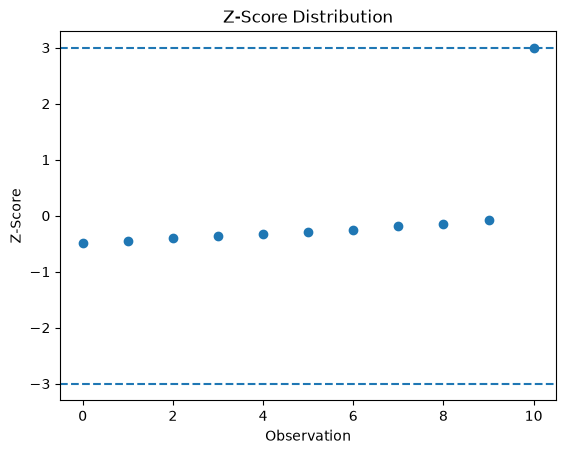

In [11]:
import matplotlib.pyplot as plt

plt.scatter(
    range(len(df)),
    df["Z_Score"]
)

plt.axhline(
    y=3,
    linestyle="--"
)

plt.axhline(
    y=-3,
    linestyle="--"
)

plt.title("Z-Score Distribution")
plt.xlabel("Observation")
plt.ylabel("Z-Score")

plt.show()